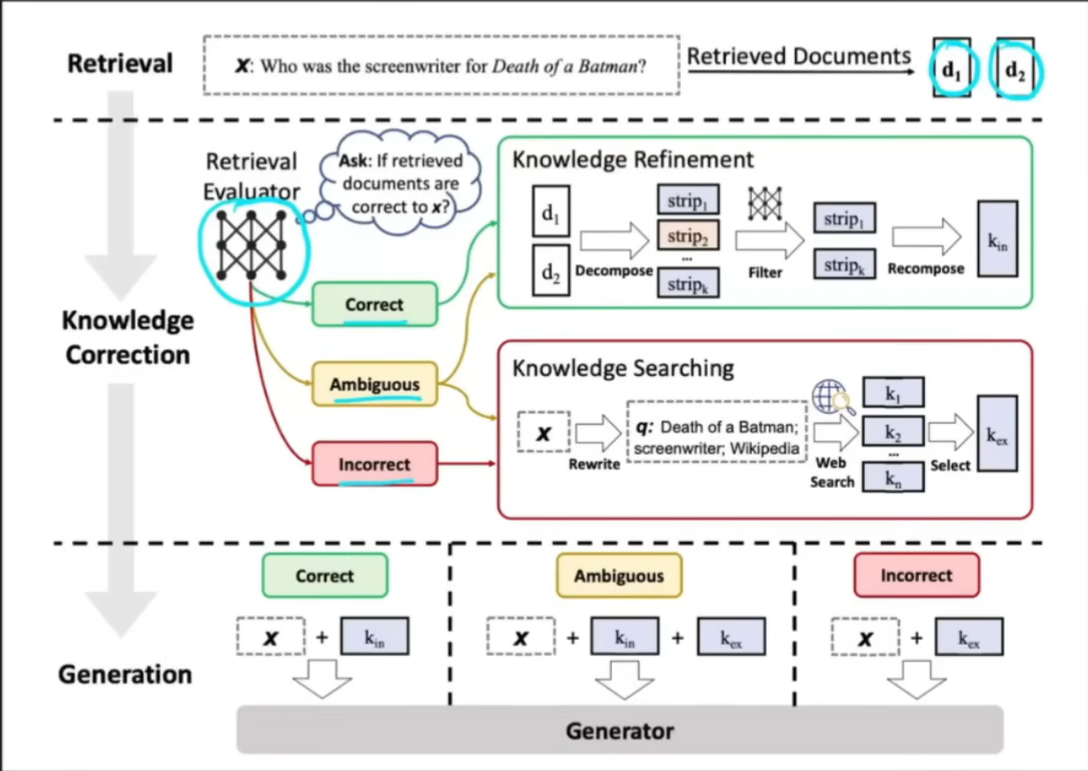

3 doc retrive thai ne aavya chhe aeno score : d1: 0.8, d2: 0.4, d3: 0.2 and uppder thresold : 0.8, lower thresold: 0.3 to doc that are use to generate the answer are d1, d2 (all the docs whose score is > lower Throsold) 

In [ ]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

llm = ChatGroq(model='qwen/qwen3.8-27b', temperature=0)
embedding = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')    

In [ ]:
# 1. just load the doc

docs = (
    TextLoader("../Document/doc.txt").load()
)

docs

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(docs)

In [ ]:
vector_store = FAISS.from_documents(chunks, embedding=embedding)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [ ]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [ ]:
# state for the Graph
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]            # output of decomposition (sentence strips)
    kept_strips: List[str]       # after filtering (kept sentences)
    refined_context: str         # recomposed internal knowledge (joined kept_strips)

    good_docs: List[Document]
    verdict:str # correct, ambiguous, incorrect
    reason: str

    answer: str

In [ ]:
# retrival tool 
def retrieve(state:State):
    que = state['question']

    return {
        "docs":retriever.invoke(que)
    }

In [ ]:
# now retrivel part is done now we have to check that all the doc is perfect or not

def decompose_to_sentences(text)->List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [ ]:
# -----------------------------
# Score-based doc evaluator
# -----------------------------

class DocEvalScore(BaseModel):
    score: float
    reason: str


doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state:State):
    '''eval. all the docs throught the llm'''

    q = state['question']

    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []


    # loop all the docs
    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})

        scores.append(out.score)
        reasons.append(out.reason)

        # good docs that have the score > LTH

        if out.score > LOWER_TH:
            good.append(d)


    # all the condition
    #1. correct
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }


    #2. incorrect 
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}",
        }

    #3. ambiguous
    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }

In [ ]:
# -----------------------------
# FILTER (LLM judge)
# -----------------------------

# like we make into the langchain 

class Output(BaseModel):
    keep : bool

prompt = ChatPromptTemplate([
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

chain = prompt | llm.with_structured_output(Output)
# this will give the list of str that only needed


def refine(state:State)->State:
    '''get all the doc split and then feed to the judge and it will give use the onlystr that can use to generate the answer'''

    q = state['question']

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["good_docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []

    for s in strips:
        if chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips":strips,
        "kept_strips":kept, 
        "refined_context":refined_context
    }


In [ ]:
# the generate node

def generate(state:State):

    system_prompt = ChatPromptTemplate(
        [
            (
                "system",
                "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
                "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
            ),
            ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
        ]
    )

    response = (system_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": response.content}

In [ ]:
def fail_node(state: State) -> State:
    return {"answer": f"FAIL: {state['reason']}"}

def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

In [ ]:
#condition
def route_after_eval(state:State):
    r = state['verdict']

    if r == 'CORRECT':
        return "refine"
    elif r == 'INCORRECT':
        return "web_search"
    else:
        return "ambiguous"

In [ ]:
#make the graph

g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("refine", refine)
g.add_node("generate", generate)
g.add_node("fail", fail_node)
g.add_node("ambiguous", ambiguous_node)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    'eval_each_doc', route_after_eval, 
    {"refine": "refine", "web_search": "fail", "ambiguous": "ambiguous"}
)

g.add_edge("refine", "generate")
g.add_edge("generate", END)
g.add_edge("fail", END)


app = g.compile()
app

In [ ]:
res = app.invoke(
    {
        "question": "What is the hottest planet?",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

In [ ]:
res

In [ ]:
res['docs'][2].page_content

In [ ]:
res['kept_strips']

In [ ]:
res['refined_context']